In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    StratifiedKFold, RepeatedStratifiedKFold, cross_validate, learning_curve, train_test_split
)
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.pipeline import Pipeline
from sklearn.base import clone

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import GridSearchCV, PredefinedSplit

In [2]:
df = pd.read_csv("../../data/feat/tweet_emotions_ptbr_with_features.csv")

df['CLEAN_TEXT'] = (
    df['CLEAN_TEXT']
    .fillna("")        # remove NaN
    .astype(str)       # garante string
)

print(df.shape)
df.head(3)

(12419, 38)


,UNCLEAN_TEXT,EMOTION,CLEAN_TEXT,letter_count,sentence_count,avg_letter_per_word,words_per_sentence,avg_syllables_per_word,reading_time,fernandez_huerta,...,sim_emotion_submissão,sim_emotion_nojo,sim_emotion_medo,sim_emotion_decepção,sim_emotion_amor,sim_emotion_remorso,sim_emotion_confianca,sim_emotion_antecipacao,sim_emotion_surpresa,sim_emotion_intimidação
0,͏ ͏ ͏ ͏ ͏ ͏ ͏ ͏\nque júbilo incalculável ver t...,alegria,que jubilo incalculavel ver todo meu querido q...,87.0,1.0,5.117647,17.0,2.000000,1.52776,69.50,...,0.257600,0.218214,0.222101,0.258962,0.273969,0.217937,0.242495,0.248363,0.222737,0.183954
1,". 𝘀𝗮𝗽𝗼𝗻𝘁𝗮𝗺𝗲𝗻𝘁𝗼𝗶\nSenhor, arranca do meu coraçã...",decepção,sapontamentoir senhor arrancar meu coracao qua...,174.0,3.0,4.461538,13.0,1.666667,2.67358,93.58,...,0.491253,0.381422,0.388554,0.460373,0.401383,0.445858,0.380126,0.313212,0.298933,0.320575
2,"A franquia continua ativa, com o desenvolvimen...",decepção,franquia continuar ativo com desenvolvimento j...,167.0,1.0,5.566667,30.0,2.366667,2.49730,34.24,...,0.051293,0.019359,0.049557,0.098947,0.040779,0.067483,0.027425,0.110073,0.102952,0.122554


In [3]:
def avaliar_cv(model, X_train, y_train, n_splits=5, n_repeats=6):
    rskf = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=42)

    # macro: trata todas as classes igualmente (classes raras importam tanto quanto classes frequentes)
    # weighted: melhor se houver desbalanceamento (penaliza menos erros em classes raras)
    scoring = {
        'accuracy': 'accuracy',
        'f1_macro': 'f1_macro',
        'precision_macro': 'precision_macro',
        'recall_macro': 'recall_macro'
    }

    results = cross_validate(
        model,
        X_train,
        y_train,
        cv=rskf,
        scoring=scoring,
    )

    accuracy_scores = results['test_accuracy']
    precision_scores = results['test_precision_macro']
    recall_scores  = results['test_recall_macro']
    f1_scores = results['test_f1_macro']

    return {
        "Accuracy":  (accuracy_scores.mean(),  accuracy_scores.std(),  accuracy_scores),
        "Precision_macro": (precision_scores.mean(), precision_scores.std(), precision_scores),
        "Recall_macro":  (recall_scores.mean(),  recall_scores.std(),  recall_scores),
        "F1_macro":   (f1_scores.mean(),   f1_scores.std(),   f1_scores),
    }

def plotar_learning_curve(model, X_train, y_train, model_name, cv=5, scoring='f1_macro'):
    train_sizes, train_scores, valid_scores = learning_curve(
        model,
        X_train,
        y_train,
        cv=StratifiedKFold(n_splits=cv, shuffle=True, random_state=42),
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring=scoring
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    valid_mean = valid_scores.mean(axis=1)
    valid_std = valid_scores.std(axis=1)

    plt.figure(figsize=(8,6))
    plt.plot(train_sizes, train_mean, 'o-', color="blue", label="Training Score")
    plt.plot(train_sizes, valid_mean, 'o-', color="orange", label="Validation Score")

    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="blue")
    plt.fill_between(train_sizes, valid_mean - valid_std, valid_mean + valid_std, alpha=0.1, color="orange")

    plt.title(f"Learning Curve - {model_name}")
    plt.xlabel("Training Set Size")
    plt.ylabel(scoring)
    plt.ylim(0, 1.05)
    plt.grid(True)
    plt.legend()
    plt.show()

def plot_feature_importance_top_k(model, feature_names, k=15, model_name="Model"):
    clf = model[-1] if hasattr(model, "__getitem__") else model

    if not hasattr(model, "feature_importances_"):
        raise ValueError("The model does not have feature_importances_.") 
    
    importances = clf.feature_importances_
    idx_sorted = np.argsort(importances)[::-1][:k]
    
    # Plot 
    plt.figure(figsize=(10, 6)) 
    plt.barh(range(k), importances[idx_sorted][::-1]) 
    plt.yticks(range(k), np.array(feature_names)[idx_sorted][::-1])
    plt.title(f"Top-{k} Feature Importances - {model_name}")
    plt.xlabel("Importance") 
    plt.tight_layout() 
    plt.show()

## (1) Optimization Without Linguistic Features

In [4]:
text_feature = "CLEAN_TEXT"

cols_input = [text_feature]

X = df[cols_input]

le = LabelEncoder()
y = le.fit_transform(df['EMOTION'])

X_train, X_aux, y_train, y_aux = train_test_split(
    X, y,
    train_size=0.70,
    random_state=42
)

X_dev, X_test, y_dev, y_test = train_test_split(
    X_aux, y_aux,
    train_size=0.50,
    random_state=42
)

print(f"Treino: {X_train.shape}, Dev: {X_dev.shape}, Teste: {X_test.shape}")

Treino: (8693, 1), Dev: (1863, 1), Teste: (1863, 1)


In [5]:
X_combined = pd.concat([X_train, X_dev])
y_combined = np.concatenate([y_train, y_dev])

split_indices = np.full(X_combined.shape[0], -1)
split_indices[len(X_train):] = 0 
ps = PredefinedSplit(test_fold=split_indices)

param_grids = {
    "LogisticRegression": [
        {
            "model__solver": ["lbfgs"],
            "model__penalty": ["l2"],
            "model__C": [0.05, 0.1, 0.5, 1.0, 5.0, 10.0],
            "model__class_weight": [None, "balanced"]
        },
        {
            "model__solver": ["saga"],
            "model__penalty": ["l1", "l2"],
            "model__C": [0.05, 0.1, 0.5, 1.0, 5.0, 10.0],
            "model__class_weight": [None, "balanced"]
        },
        {
            "model__solver": ["saga"],
            "model__penalty": ["elasticnet"],
            "model__C": [0.05, 0.1, 0.5, 1.0, 5.0, 10.0],
            "model__l1_ratio": [0.15, 0.5, 0.85],
            "model__class_weight": [None, "balanced"]
        }
    ],
    "RidgeClassifier": {
        "model__alpha": [0.05, 0.1, 0.5, 1.0, 5.0, 10.0],
        "model__fit_intercept": [True, False],
        "model__class_weight": [None, "balanced"]
    },
    "LinearSVC": {
        "model__estimator__C": [0.01, 0.1, 1, 10, 100],
        "model__estimator__loss": ["hinge", "squared_hinge"],
        "model__estimator__class_weight": [None, "balanced"]
    },
    "RandomForest": {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [None, 10, 25, 50],
        "model__min_samples_leaf": [1, 5, 10],
        "model__max_features": ["sqrt", 0.3, 0.5],
        "model__class_weight": [None, "balanced_subsample"]
    },
    "XGBClassifier": {
        "model__learning_rate": [0.05, 0.1],
        "model__n_estimators": [200, 400],
        "model__max_depth": [3, 5],
        "model__min_child_weight": [5, 10],
        "model__subsample": [0.8, 1.0],
        "model__colsample_bytree": [0.8, 1.0],
        "model__gamma": [0, 1.0],
        "model__reg_alpha": [0.0, 0.1],
        "model__reg_lambda": [1.0, 5.0]
    }
}


Running GridSearch for: LogisticRegression
Params Vectorizer: {'max_features': 2000}
Fitting 1 folds for each of 72 candidates, totalling 72 fits
Best params for LogisticRegression

{'model__C': 1.0, 'model__class_weight': None, 'model__penalty': 'l1', 'model__solver': 'saga'}


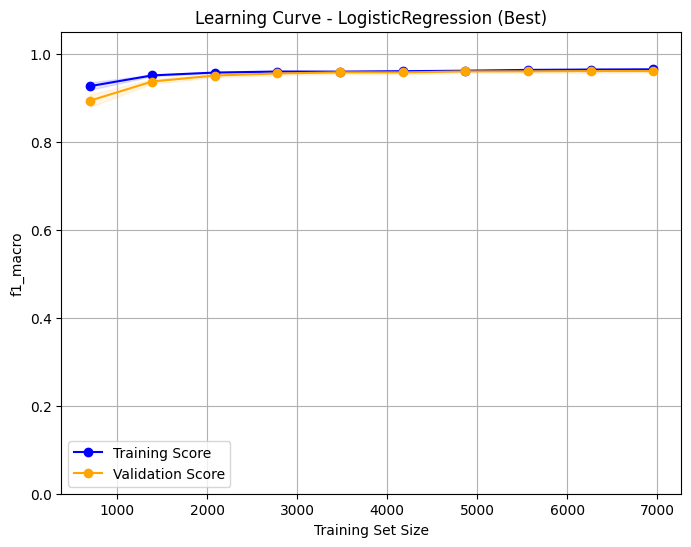


Running GridSearch for: RidgeClassifier
Params Vectorizer: {'max_features': 7000}
Fitting 1 folds for each of 24 candidates, totalling 24 fits
Best params for RidgeClassifier

{'model__alpha': 1.0, 'model__class_weight': 'balanced', 'model__fit_intercept': True}


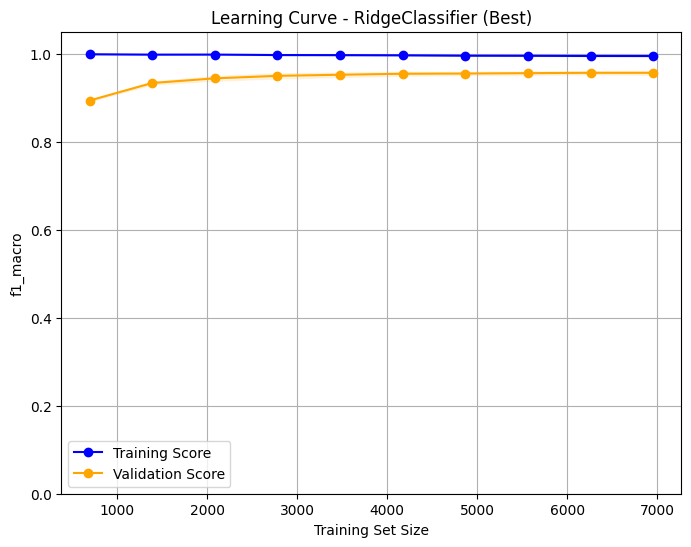


Running GridSearch for: LinearSVC
Params Vectorizer: {'max_features': 5000}
Fitting 1 folds for each of 20 candidates, totalling 20 fits


c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-d

Best params for LinearSVC

{'model__estimator__C': 1, 'model__estimator__class_weight': None, 'model__estimator__loss': 'hinge'}


c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-d

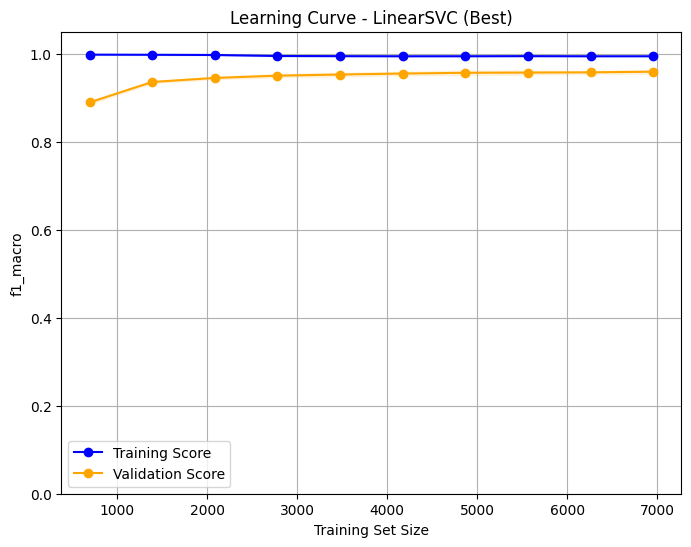

c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(



Running GridSearch for: RandomForest
Params Vectorizer: {'max_features': 6000, 'ngram_range': (1, 2)}
Fitting 1 folds for each of 216 candidates, totalling 216 fits
Best params for RandomForest

{'model__class_weight': None, 'model__max_depth': 50, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__n_estimators': 200}


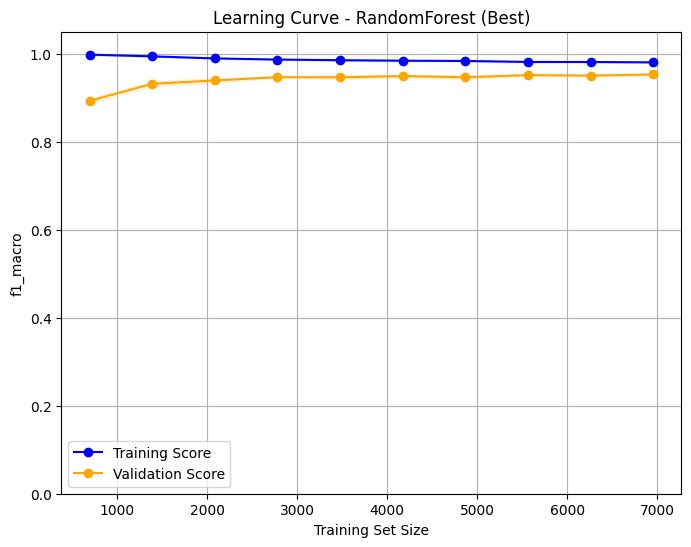


Running GridSearch for: XGBClassifier
Params Vectorizer: {'max_features': 6000, 'ngram_range': (1, 3)}
Fitting 1 folds for each of 512 candidates, totalling 512 fits
Best params for XGBClassifier

{'model__colsample_bytree': 1.0, 'model__gamma': 1.0, 'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__min_child_weight': 5, 'model__n_estimators': 400, 'model__reg_alpha': 0.0, 'model__reg_lambda': 5.0, 'model__subsample': 1.0}


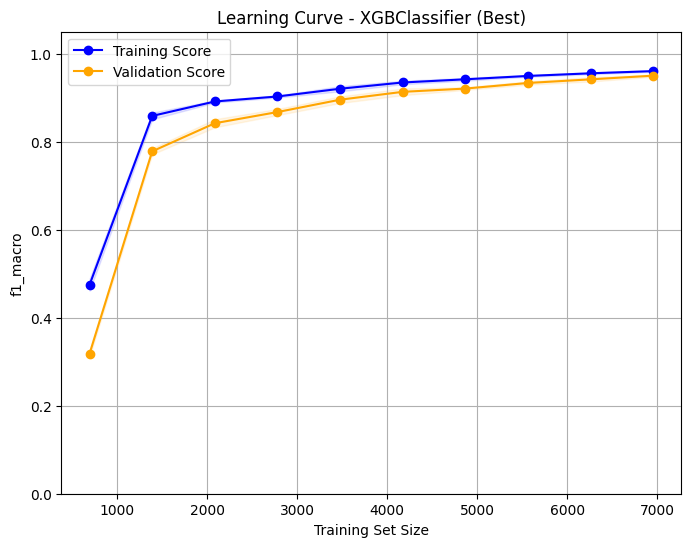

In [6]:
best_vect_params = {
    "LogisticRegression":   {"max_features": 2000},
    "RidgeClassifier":      {"max_features": 7000},
    "LinearSVC":            {"max_features": 5000},
    "RandomForest":         {"max_features": 6000, "ngram_range": (1, 2)},
    "XGBClassifier":        {"max_features": 6000, "ngram_range": (1, 3)},
}

models_for_testing = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "RidgeClassifier": RidgeClassifier(random_state=42),
    "LinearSVC": OneVsRestClassifier(LinearSVC(random_state=42)),
    "RandomForest": RandomForestClassifier(random_state=42),
    "XGBClassifier": XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42,
        verbosity=0
    )
}

results = []

def run_optimizations(name, model, X_train, y_train, vect_params):
    print("\n" + "=" * 80)
    print(f"Running GridSearch for: {name}")
    print(f"Params Vectorizer: {vect_params}")
    print("=" * 80)

    vectorizer = TfidfVectorizer(**vect_params)

    preprocessor = ColumnTransformer(
        transformers=[
            ('tfidf', vectorizer, text_feature),
        ],
        remainder='drop'
    )

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    grid_search = GridSearchCV(
        estimator=pipe,
        param_grid=param_grids.get(name, {}),
        cv=ps,
        scoring='f1_macro',
        verbose=1
    )

    grid_search.fit(X_combined, y_combined)
    best_pipe = grid_search.best_estimator_

    print(f"Best params for {name}\n")
    print(grid_search.best_params_)

    cv_res = avaliar_cv(clone(best_pipe), X_train, y_train, n_splits=5, n_repeats=6)

    plotar_learning_curve(clone(best_pipe), X_train, y_train, model_name=f"{name} (Best)", cv=5, scoring="f1_macro")

    best_pipe = clone(best_pipe)
    best_pipe.fit(X_train, y_train)

    y_dev_pred = best_pipe.predict(X_dev)

    dev_accuracy = accuracy_score(y_dev, y_dev_pred)
    dev_precision_macro = precision_score(y_dev, y_dev_pred, average="macro", zero_division=0)
    dev_recall_macro = recall_score(y_dev, y_dev_pred, average="macro", zero_division=0)
    dev_f1_macro = f1_score(y_dev, y_dev_pred, average="macro", zero_division=0)

    results.append({
        "Model": name,
        "Best_Pipeline": best_pipe,
        "Best_Params": grid_search.best_params_,

        "CV_Accuracy_mean":  cv_res["Accuracy"][0],
        "CV_Accuracy_std":   cv_res["Accuracy"][1],
        "CV_Accuracy_all":   cv_res["Accuracy"][2],
        "CV_Precision_macro_mean":  cv_res["Precision_macro"][0],
        "CV_Precision_macro_std":   cv_res["Precision_macro"][1],
        "CV_Precision_macro_all":   cv_res["Precision_macro"][2],
        "CV_Recall_macro_mean":  cv_res["Recall_macro"][0],
        "CV_Recall_macro_std":   cv_res["Recall_macro"][1],
        "CV_Recall_macro_all":   cv_res["Recall_macro"][2],
        "CV_F1_macro_mean":  cv_res["F1_macro"][0],
        "CV_F1_macro_std":   cv_res["F1_macro"][1],
        "CV_F1_macro_all":   cv_res["F1_macro"][2],

        # DEV
        "DEV_Accuracy":  dev_accuracy,
        "DEV_Precision_macro": dev_precision_macro,
        "DEV_Recall_macro": dev_recall_macro,
        "DEV_F1_macro": dev_f1_macro,
    })

for name, model in models_for_testing.items():
    params = best_vect_params.get(name, {})
    run_optimizations(name, model, X_train, y_train, params)

In [9]:
df_results = pd.DataFrame(results)

def format_results(df):
    formatted_df = df.copy()

    for metric in ["Accuracy", "Precision_macro", "Recall_macro", "F1_macro"]:
        mean_col = f"CV_{metric}_mean"
        std_col = f"CV_{metric}_std"

        formatted_df[metric] = (
            formatted_df[mean_col].round(4).astype(str)
            + " ± "
            + formatted_df[std_col].round(4).astype(str)
        )

        # Remove as colunas originais
        formatted_df = formatted_df.drop(columns=[mean_col, std_col])

    # reorganiza colunas
    cols = ["Model", "Accuracy", "Precision_macro", "Recall_macro", "F1_macro"]
    return formatted_df[cols]

df_results.to_csv("../../data/out/model_optimization/without_linguistic_features/mopt_03_TweetEmotionsPTBR_TFIDF.csv", index=False)
formatted_df = format_results(df_results)
formatted_df.style.hide(axis="index")

Model,Accuracy,Precision_macro,Recall_macro,F1_macro
LogisticRegression,0.9583 ± 0.005,0.9669 ± 0.0037,0.9587 ± 0.005,0.9611 ± 0.0045
RidgeClassifier,0.9562 ± 0.0055,0.9571 ± 0.0054,0.9568 ± 0.0054,0.9566 ± 0.0054
LinearSVC,0.958 ± 0.0052,0.9589 ± 0.0052,0.9586 ± 0.0051,0.9584 ± 0.0052
RandomForest,0.9498 ± 0.0049,0.9569 ± 0.0042,0.9503 ± 0.0047,0.9521 ± 0.0045
XGBClassifier,0.9456 ± 0.0068,0.9601 ± 0.0049,0.9459 ± 0.0067,0.9499 ± 0.006


In [10]:
def format_results_dev(df):
    cols = ["Model", "DEV_Accuracy", "DEV_Precision_macro", "DEV_Recall_macro", "DEV_F1_macro"]
    return df[cols].round(4)

df_dev = format_results_dev(df_results)

df_dev.style.hide(axis="index")

Model,DEV_Accuracy,DEV_Precision_macro,DEV_Recall_macro,DEV_F1_macro
LogisticRegression,0.954400,0.964300,0.954900,0.958000
RidgeClassifier,0.949000,0.951000,0.950100,0.950200
LinearSVC,0.951700,0.952700,0.952600,0.952500
RandomForest,0.949000,0.958900,0.949800,0.952600
XGBClassifier,0.949500,0.965300,0.950000,0.954800


In [11]:
list_best_params = []

def extract_pipeline_params(pipeline):
    params = {}

    for step_name, step in pipeline.named_steps.items():
        step_params = step.get_params(deep=False)
        for k, v in step_params.items():
            params[f"{step_name}__{k}"] = v

    return params

for _, row in df_results.iterrows():
    model = row["Model"]
    pipeline = row["Best_Pipeline"]

    params = extract_pipeline_params(pipeline)

    filtered_params = {
        k: v for k, v in params.items()
        if any(x in k for x in ["preprocessor__tfidf__", "model__"])
    }

    list_best_params.append({
        "Model": model,
        "Best Params": filtered_params
    })

df_params = pd.DataFrame(list_best_params)

def format_dict_params(param_dict):
    return ", ".join([f"{k}={v}" for k, v in param_dict.items()])

df_params["Best_Params_Formatted"] = (
    df_params["Best Params"]
    .apply(format_dict_params)
)

df_parametros_formatado = df_params[
    ["Model", "Best_Params_Formatted"]
]

df_params.to_csv("../../data/out/model_optimization/without_linguistic_features/mopt_03_TweetEmotionsPTBR_TFIDF_params.csv", index=False)
df_params

,Model,Best Params,Best_Params_Formatted
0,LogisticRegression,"{'model__C': 1.0, 'model__class_weight': None,...","model__C=1.0, model__class_weight=None, model_..."
1,RidgeClassifier,"{'model__alpha': 1.0, 'model__class_weight': '...","model__alpha=1.0, model__class_weight=balanced..."
2,LinearSVC,"{'model__estimator': LinearSVC(C=1, loss='hing...","model__estimator=LinearSVC(C=1, loss='hinge', ..."
3,RandomForest,"{'model__bootstrap': True, 'model__ccp_alpha':...","model__bootstrap=True, model__ccp_alpha=0.0, m..."
4,XGBClassifier,"{'model__objective': 'multi:softprob', 'model_...","model__objective=multi:softprob, model__base_s..."


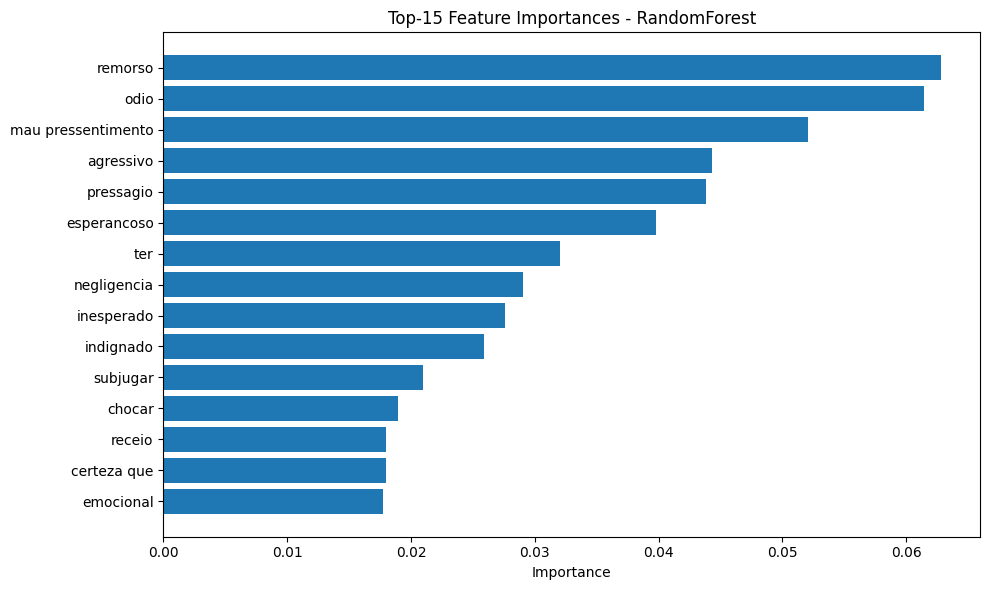

In [12]:
best_pipeline = df_results.loc[
    df_results["Model"] == "RandomForest",
    "Best_Pipeline"
].iloc[0]

rf_model = best_pipeline.named_steps["model"]
preprocessor = best_pipeline.named_steps["preprocessor"]

rf_feature_names = best_pipeline["preprocessor"]["tfidf"].get_feature_names_out()

plot_feature_importance_top_k(rf_model, rf_feature_names, k=15, model_name="RandomForest")

## (2) Optimization With Linguistic Features

In [5]:
text_feature = "CLEAN_TEXT"

numerical_features = [
    "flesch_portuguese", "letter_count", "sentence_count", "avg_letter_per_word", "words_per_sentence", "avg_syllables_per_word", "reading_time", 
    "fernandez_huerta", "szigriszt_pazos", "gutierrez_polini", "punctuation_per_word", "exclamation_per_word", "question_per_word", "mean_verbs_per_word", 
    "mean_auxiliaries_per_word", "mean_auxiliaries_per_sentence", "uppercase_percentage", "mean_unique_word_length", "mean_char_repetition_per_word", 
    "sim_emotion_tristeza", "sim_emotion_otimismo", "sim_emotion_desprezo", "sim_emotion_alegria", "sim_emotion_raiva", "sim_emotion_agressividade",
    "sim_emotion_submissão", "sim_emotion_nojo", "sim_emotion_medo", "sim_emotion_decepção", "sim_emotion_amor", "sim_emotion_remorso", "sim_emotion_confianca",
    "sim_emotion_antecipacao", "sim_emotion_surpresa", "sim_emotion_intimidação"
]

cols_input = [text_feature] + numerical_features

X = df[cols_input]

le = LabelEncoder()
y = le.fit_transform(df['EMOTION'])

X_train, X_aux, y_train, y_aux = train_test_split(
    X, y,
    train_size=0.70,
    random_state=42
)

X_dev, X_test, y_dev, y_test = train_test_split(
    X_aux, y_aux,
    train_size=0.50,
    random_state=42
)

print(f"Treino: {X_train.shape}, Dev: {X_dev.shape}, Teste: {X_test.shape}")

Treino: (8693, 36), Dev: (1863, 36), Teste: (1863, 36)


In [6]:
X_combined = pd.concat([X_train, X_dev])
y_combined = np.concatenate([y_train, y_dev])

split_indices = np.full(X_combined.shape[0], -1)
split_indices[len(X_train):] = 0 
ps = PredefinedSplit(test_fold=split_indices)

param_grids = {
    "LogisticRegression": [
        {
            "model__solver": ["lbfgs"],
            "model__penalty": ["l2"],
            "model__C": [0.05, 0.1, 0.5, 1.0, 5.0, 10.0],
            "model__class_weight": [None, "balanced"]
        },
        {
            "model__solver": ["saga"],
            "model__penalty": ["l1", "l2"],
            "model__C": [0.05, 0.1, 0.5, 1.0, 5.0, 10.0],
            "model__class_weight": [None, "balanced"]
        },
        {
            "model__solver": ["saga"],
            "model__penalty": ["elasticnet"],
            "model__C": [0.05, 0.1, 0.5, 1.0, 5.0, 10.0],
            "model__l1_ratio": [0.15, 0.5, 0.85],
            "model__class_weight": [None, "balanced"]
        }
    ],
    "RidgeClassifier": {
        "model__alpha": [0.05, 0.1, 0.5, 1.0, 5.0, 10.0],
        "model__fit_intercept": [True, False],
        "model__class_weight": [None, "balanced"]
    },
    "LinearSVC": {
        "model__estimator__C": [0.01, 0.1, 1, 10, 100],
        "model__estimator__loss": ["hinge", "squared_hinge"],
        "model__estimator__class_weight": [None, "balanced"]
    },
    "RandomForest": {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [None, 10, 25, 50],
        "model__min_samples_leaf": [1, 5, 10],
        "model__max_features": ["sqrt", 0.3, 0.5],
        "model__class_weight": [None, "balanced_subsample"]
    },
    "XGBClassifier": {
        "model__learning_rate": [0.05, 0.1],
        "model__n_estimators": [200, 400],
        "model__max_depth": [3, 5],
        "model__min_child_weight": [5, 10],
        "model__subsample": [0.8, 1.0],
        "model__colsample_bytree": [0.8, 1.0],
        "model__gamma": [0, 1.0],
        "model__reg_alpha": [0.0, 0.1],
        "model__reg_lambda": [1.0, 5.0]
    }
}


Running GridSearch for: LogisticRegression
Params Vectorizer: {'max_features': 2000}
Fitting 1 folds for each of 72 candidates, totalling 72 fits


c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\redga\OneDrive\Área de Trabalho\UFJ

Best params for LogisticRegression

{'model__C': 10.0, 'model__class_weight': None, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}


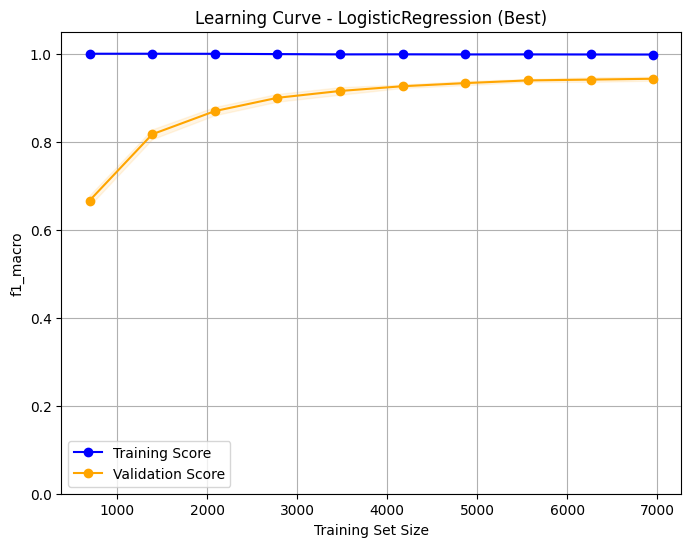


Running GridSearch for: RidgeClassifier
Params Vectorizer: {'max_features': 7000}
Fitting 1 folds for each of 24 candidates, totalling 24 fits
Best params for RidgeClassifier

{'model__alpha': 1.0, 'model__class_weight': None, 'model__fit_intercept': True}


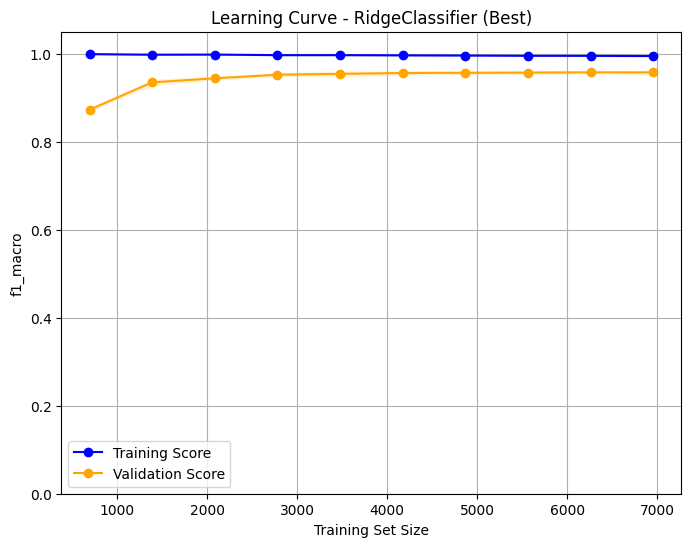


Running GridSearch for: LinearSVC
Params Vectorizer: {'max_features': 5000}
Fitting 1 folds for each of 20 candidates, totalling 20 fits


c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-d

Best params for LinearSVC

{'model__estimator__C': 1, 'model__estimator__class_weight': None, 'model__estimator__loss': 'squared_hinge'}


c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-d

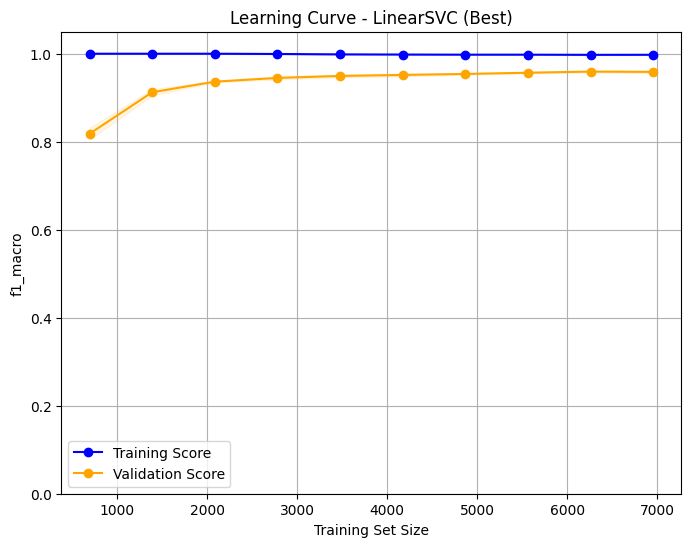


Running GridSearch for: RandomForest
Params Vectorizer: {'max_features': 6000, 'ngram_range': (1, 2)}
Fitting 1 folds for each of 216 candidates, totalling 216 fits


In [ ]:
best_vect_params = {
    "LogisticRegression":   {"max_features": 2000},
    "RidgeClassifier":      {"max_features": 7000},
    "LinearSVC":            {"max_features": 5000},
    "RandomForest":         {"max_features": 6000, "ngram_range": (1, 2)},
    "XGBClassifier":        {"max_features": 6000, "ngram_range": (1, 3)},
}

models_for_testing = {
    "LogisticRegression": LogisticRegression(max_iter=2000, random_state=42),
    "RidgeClassifier": RidgeClassifier(random_state=42),
    "LinearSVC": OneVsRestClassifier(LinearSVC(random_state=42)),
    "RandomForest": RandomForestClassifier(random_state=42),
    "XGBClassifier": XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42,
        verbosity=0
    )
}

results = []

def run_optimizations(name, model, X_train, y_train, vect_params):
    print("\n" + "=" * 80)
    print(f"Running GridSearch for: {name}")
    print(f"Params Vectorizer: {vect_params}")
    print("=" * 80)

    vectorizer = TfidfVectorizer(**vect_params)

    preprocessor = ColumnTransformer(
        transformers=[
            ('tfidf', vectorizer, text_feature),
            ('scaler', StandardScaler(), numerical_features)
        ],
        remainder='drop'
    )

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    grid_search = GridSearchCV(
        estimator=pipe,
        param_grid=param_grids.get(name, {}),
        cv=ps,
        scoring='f1_macro',
        verbose=1
    )

    grid_search.fit(X_combined, y_combined)
    best_pipe = grid_search.best_estimator_

    print(f"Best params for {name}\n")
    print(grid_search.best_params_)

    cv_res = avaliar_cv(clone(best_pipe), X_train, y_train, n_splits=5, n_repeats=6)

    plotar_learning_curve(clone(best_pipe), X_train, y_train, model_name=f"{name} (Best)", cv=5, scoring="f1_macro")

    best_pipe = clone(best_pipe)
    best_pipe.fit(X_train, y_train)

    y_dev_pred = best_pipe.predict(X_dev)

    dev_accuracy = accuracy_score(y_dev, y_dev_pred)
    dev_precision_macro = precision_score(y_dev, y_dev_pred, average="macro", zero_division=0)
    dev_recall_macro = recall_score(y_dev, y_dev_pred, average="macro", zero_division=0)
    dev_f1_macro = f1_score(y_dev, y_dev_pred, average="macro", zero_division=0)

    results.append({
        "Model": name,
        "Best_Pipeline": best_pipe,
        "Best_Params": grid_search.best_params_,

        "CV_Accuracy_mean":  cv_res["Accuracy"][0],
        "CV_Accuracy_std":   cv_res["Accuracy"][1],
        "CV_Accuracy_all":   cv_res["Accuracy"][2],
        "CV_Precision_macro_mean":  cv_res["Precision_macro"][0],
        "CV_Precision_macro_std":   cv_res["Precision_macro"][1],
        "CV_Precision_macro_all":   cv_res["Precision_macro"][2],
        "CV_Recall_macro_mean":  cv_res["Recall_macro"][0],
        "CV_Recall_macro_std":   cv_res["Recall_macro"][1],
        "CV_Recall_macro_all":   cv_res["Recall_macro"][2],
        "CV_F1_macro_mean":  cv_res["F1_macro"][0],
        "CV_F1_macro_std":   cv_res["F1_macro"][1],
        "CV_F1_macro_all":   cv_res["F1_macro"][2],

        # DEV
        "DEV_Accuracy":  dev_accuracy,
        "DEV_Precision_macro": dev_precision_macro,
        "DEV_Recall_macro": dev_recall_macro,
        "DEV_F1_macro": dev_f1_macro,
    })

for name, model in models_for_testing.items():
    params = best_vect_params.get(name, {})
    run_optimizations(name, model, X_train, y_train, params)

In [ ]:
df_results = pd.DataFrame(results)

def format_results(df):
    formatted_df = df.copy()

    for metric in ["Accuracy", "Precision_macro", "Recall_macro", "F1_macro"]:
        mean_col = f"CV_{metric}_mean"
        std_col = f"CV_{metric}_std"

        formatted_df[metric] = (
            formatted_df[mean_col].round(4).astype(str)
            + " ± "
            + formatted_df[std_col].round(4).astype(str)
        )

        # Remove as colunas originais
        formatted_df = formatted_df.drop(columns=[mean_col, std_col])

    # reorganiza colunas
    cols = ["Model", "Accuracy", "Precision_macro", "Recall_macro", "F1_macro"]
    return formatted_df[cols]

df_results.to_csv("../../data/out/model_optimization/with_linguistic_features/mopt_03_TweetEmotionsPTBR_TFIDF.csv", index=False)
formatted_df = format_results(df_results)
formatted_df.style.hide(axis="index")

In [ ]:
def format_results_dev(df):
    cols = ["Model", "DEV_Accuracy", "DEV_Precision_macro", "DEV_Recall_macro", "DEV_F1_macro"]
    return df[cols].round(4)

df_dev = format_results_dev(df_results)

df_dev.style.hide(axis="index")

In [ ]:
list_best_params = []

def extract_pipeline_params(pipeline):
    params = {}

    for step_name, step in pipeline.named_steps.items():
        step_params = step.get_params(deep=False)
        for k, v in step_params.items():
            params[f"{step_name}__{k}"] = v

    return params

for _, row in df_results.iterrows():
    model = row["Model"]
    pipeline = row["Best_Pipeline"]

    params = extract_pipeline_params(pipeline)

    filtered_params = {
        k: v for k, v in params.items()
        if any(x in k for x in ["preprocessor__tfidf__", "model__"])
    }

    list_best_params.append({
        "Model": model,
        "Best Params": filtered_params
    })

df_params = pd.DataFrame(list_best_params)

def format_dict_params(param_dict):
    return ", ".join([f"{k}={v}" for k, v in param_dict.items()])

df_params["Best_Params_Formatted"] = (
    df_params["Best Params"]
    .apply(format_dict_params)
)

df_parametros_formatado = df_params[
    ["Model", "Best_Params_Formatted"]
]

df_params.to_csv("../../data/out/model_optimization/with_linguistic_features/mopt_03_TweetEmotionsPTBR_TFIDF_params.csv", index=False)
df_params

In [ ]:
best_pipeline = df_results.loc[
    df_results["Model"] == "RandomForest",
    "Best_Pipeline"
].iloc[0]

rf_model = best_pipeline.named_steps["model"]
preprocessor = best_pipeline.named_steps["preprocessor"]

tfidf = preprocessor.named_transformers_["tfidf"]
tfidf_features = tfidf.get_feature_names_out()

num_features = numerical_features

all_feature_names = np.concatenate([
    tfidf_features,
    num_features
])

importances = rf_model.feature_importances_

feat_imp = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

top15 = feat_imp.head(15)

plt.figure(figsize=(8, 6))
sns.barplot(
    data=top15,
    x="importance",
    y="feature"
)
plt.title("Top 15 Most Important Features (TF-IDF + Linguistic)")
plt.tight_layout()
plt.show()

tfidf_set = set(tfidf_features)

feat_imp["type"] = feat_imp["feature"].apply(
    lambda f: "text" if f in tfidf_set else "numeric"
)

agg_imp = (
    feat_imp
    .groupby("type")["importance"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(5, 4))
sns.barplot(
    data=agg_imp,
    x="type",
    y="importance"
)
plt.title("Aggregate Importance by Feature Type")
plt.tight_layout()
plt.show()

num_imp = (
    feat_imp[feat_imp["type"] == "numeric"]
    .sort_values(by="importance", ascending=False)
    .head(15)
)

plt.figure(figsize=(8, 6))
sns.barplot(
    data=num_imp,
    x="importance",
    y="feature"
)
plt.title("Top 15 Most Important Linguistic Features")
plt.tight_layout()
plt.show()